# Day 6–7 — Feature Engineering & Planning

Goal: create new features, encode categoricals, and produce a model-ready dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_churn.csv')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## New Feature 1 — tenure_bucket

New customers (<1 year) churn most. Bucketing makes this non-linear signal usable by linear models.

In [2]:
# Buckets based on EDA: new (0-12 mo), mid (13-48 mo), long (49+ mo)
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 48, df['tenure'].max() + 1],
    labels=['new', 'mid', 'long'],
    right=True
)

# Validate churn rates per bucket
print('Churn rate per tenure bucket:')
print(df.groupby('tenure_bucket')['Churn'].mean().map('{:.1%}'.format))

Churn rate per tenure bucket:
tenure_bucket
new     47.7%
mid     23.6%
long     9.5%
Name: Churn, dtype: str


## New Feature 2 — high_charges flag

$70/month is above the dataset median. Customers paying above this with no contract commitment are at high risk.

In [3]:
threshold = df['MonthlyCharges'].median()
df['high_charges'] = (df['MonthlyCharges'] > threshold).astype(int)

print(f'Threshold used (median): ${threshold:.2f}')
print('Churn rate — low vs high charges:')
print(df.groupby('high_charges')['Churn'].mean().map('{:.1%}'.format))

Threshold used (median): $70.35
Churn rate — low vs high charges:
high_charges
0    18.0%
1    35.2%
Name: Churn, dtype: str


## New Feature 3 — num_services

Count of add-on services. Customers with more services may be more embedded (less likely to churn).

In [4]:
SERVICE_COLS = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['num_services'] = df[SERVICE_COLS].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print('Services count distribution:')
print(df['num_services'].value_counts().sort_index())
print()
print('Churn rate by number of services:')
print(df.groupby('num_services')['Churn'].mean().map('{:.1%}'.format))

Services count distribution:
num_services
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64

Churn rate by number of services:
num_services
0    21.5%
1    45.8%
2    35.8%
3    27.4%
4    22.4%
5    12.5%
6     5.3%
Name: Churn, dtype: str


## Visualise new features vs churn

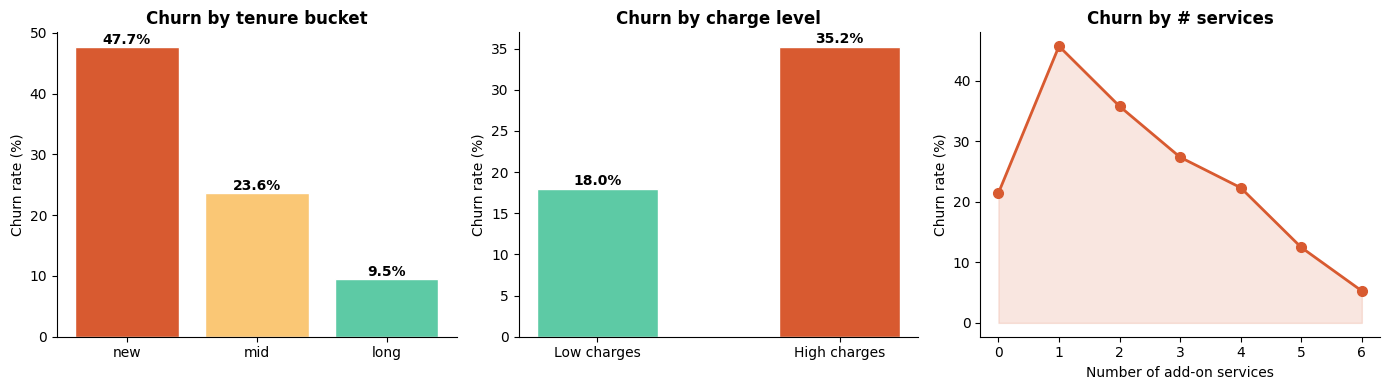

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# tenure_bucket
tb = df.groupby('tenure_bucket')['Churn'].mean() * 100
axes[0].bar(tb.index.astype(str), tb.values, color=['#D85A30', '#FAC775', '#5DCAA5'], edgecolor='white')
axes[0].set_title('Churn by tenure bucket', fontweight='bold')
axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(tb.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# high_charges
hc = df.groupby('high_charges')['Churn'].mean() * 100
axes[1].bar(['Low charges', 'High charges'], hc.values, color=['#5DCAA5', '#D85A30'], edgecolor='white', width=0.5)
axes[1].set_title('Churn by charge level', fontweight='bold')
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(hc.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# num_services
ns = df.groupby('num_services')['Churn'].mean() * 100
axes[2].plot(ns.index, ns.values, marker='o', color='#D85A30', linewidth=2, markersize=7)
axes[2].fill_between(ns.index, ns.values, alpha=0.15, color='#D85A30')
axes[2].set_title('Churn by # services', fontweight='bold')
axes[2].set_xlabel('Number of add-on services')
axes[2].set_ylabel('Churn rate (%)')
axes[2].set_xticks(ns.index)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../images/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Final feature list decision

### Drop these columns
- `TotalCharges` — highly correlated with `tenure` (r > 0.8), redundant

### Keep / Encode these
| Column | Type | Notes |
|---|---|---|
| gender | categorical | binary encode |
| SeniorCitizen | numeric | already 0/1 |
| Partner | categorical | binary |
| Dependents | categorical | binary |
| tenure | numeric | keep as-is |
| PhoneService | categorical | binary |
| MultipleLines | categorical | 3-way |
| InternetService | categorical | 3-way |
| OnlineSecurity … StreamingMovies | categorical | binary (Yes/No/No internet) |
| Contract | categorical | 3-way — strong predictor |
| PaperlessBilling | categorical | binary |
| PaymentMethod | categorical | 4-way |
| MonthlyCharges | numeric | keep as-is |
| tenure_bucket | categorical (new) | ordinal |
| high_charges | numeric (new) | 0/1 |
| num_services | numeric (new) | 0–6 count |

In [6]:
# Drop TotalCharges (redundant with tenure)
df.drop(columns=['TotalCharges'], inplace=True)

# Encode gender and binary Yes/No columns
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# One-hot encode multi-category columns
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Encode tenure_bucket ordinal
bucket_map = {'new': 0, 'mid': 1, 'long': 2}
df['tenure_bucket'] = df['tenure_bucket'].map(bucket_map)

print(f'Final shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Final shape: (7032, 33)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'tenure_bucket', 'high_charges', 'num_services', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [7]:
# Confirm no nulls, all numeric
print('Null count:', df.isnull().sum().sum())
print('All numeric?', (df.dtypes == 'object').sum() == 0)
df.head(3)

Null count: 0
All numeric? True


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,tenure_bucket,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,0,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,0,1,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,1,0,...,False,False,False,False,False,False,False,False,False,True


In [9]:
# Save model-ready dataset
df.to_csv('../data/processed/featured_churn.csv', index=False)
print('Saved → data/processed/featured_churn.csv')
print(f'Shape: {df.shape}')

Saved → data/processed/featured_churn.csv
Shape: (7032, 33)
